In [115]:
# Import statement
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


## Import Data

In [116]:
data = load_digits()
df = pd.DataFrame(data.data, columns=data.feature_names)
X = data.data
y = data.target
print(df.head(5))

   pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
0        0.0        0.0        5.0       13.0        9.0        1.0   
1        0.0        0.0        0.0       12.0       13.0        5.0   
2        0.0        0.0        0.0        4.0       15.0       12.0   
3        0.0        0.0        7.0       15.0       13.0        1.0   
4        0.0        0.0        0.0        1.0       11.0        0.0   

   pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_6  pixel_6_7  \
0        0.0        0.0        0.0        0.0  ...        0.0        0.0   
1        0.0        0.0        0.0        0.0  ...        0.0        0.0   
2        0.0        0.0        0.0        0.0  ...        5.0        0.0   
3        0.0        0.0        0.0        8.0  ...        9.0        0.0   
4        0.0        0.0        0.0        0.0  ...        0.0        0.0   

   pixel_7_0  pixel_7_1  pixel_7_2  pixel_7_3  pixel_7_4  pixel_7_5  \
0        0.0        0.0        6.0       13.0

## EDA

In [117]:
print(df.shape)
print(data.target_names)
df.describe()

(1797, 64)
[0 1 2 3 4 5 6 7 8 9]


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


The load_digits() dataset from scikit-learn was loaded for this experiment. This dataset contains 1797 grayscale images of handwritten digits, each represented as an 8×8 image (64 features). The feature matrix X contains pixel intensity values ranging from 0 to 16, and the target vector y contains the corresponding digit labels from 0 to 9.

In [118]:
df['target'] = y
print(df.groupby('target').size())

target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
dtype: int64


The class distribution shows that each digit appears approximately the same number of times, indicating that the dataset is well balanced. Since there is no severe class imbalance, evaluation metrics such as accuracy, precision, recall, and F1-score are appropriate and reliable for performance assessment.

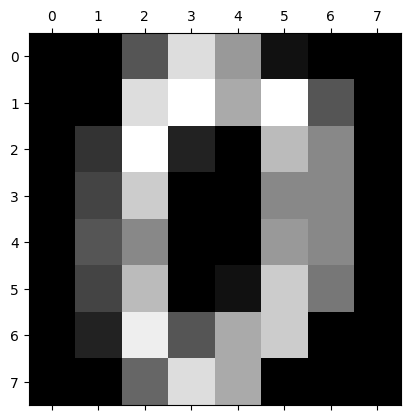

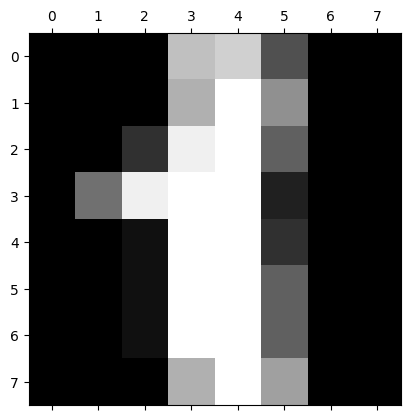

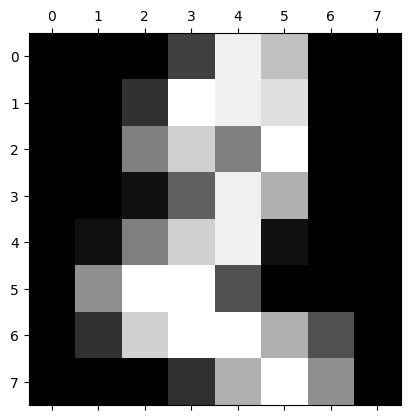

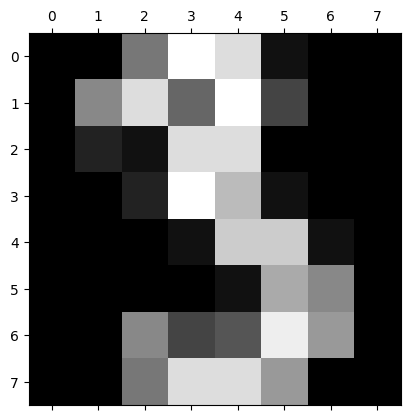

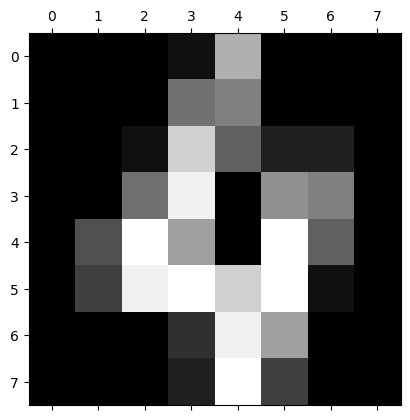

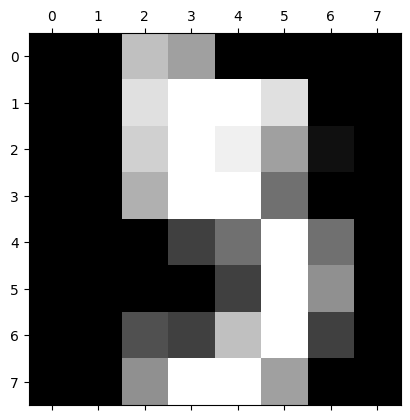

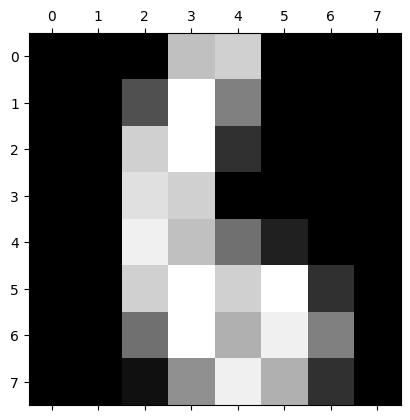

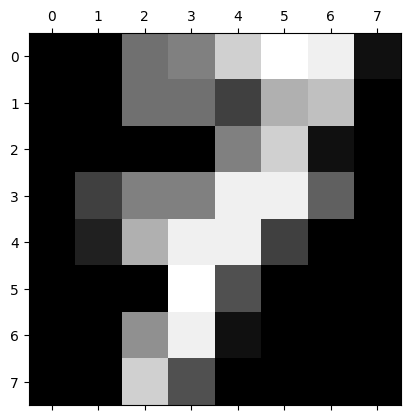

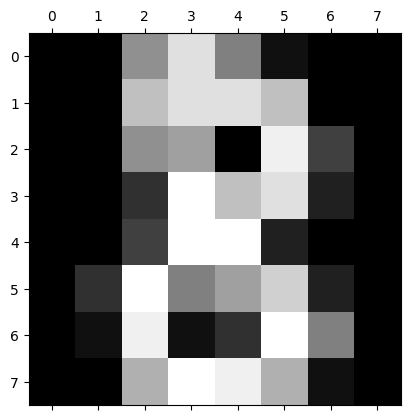

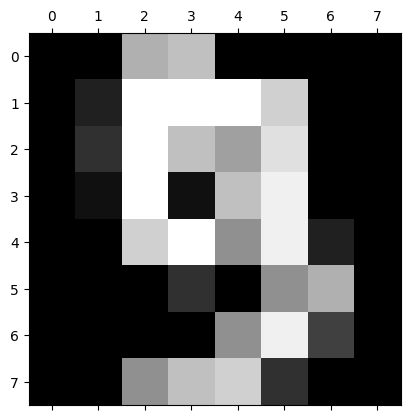

In [119]:
digits = load_digits()
plt.matshow(digits.images[0], cmap="gray")
plt.matshow(digits.images[1], cmap="gray")
plt.matshow(digits.images[2], cmap="gray")
plt.matshow(digits.images[3], cmap="gray")
plt.matshow(digits.images[4], cmap="gray")
plt.matshow(digits.images[5], cmap="gray")
plt.matshow(digits.images[6], cmap="gray")
plt.matshow(digits.images[7], cmap="gray")
plt.matshow(digits.images[8], cmap="gray")
plt.matshow(digits.images[9], cmap="gray")

In [120]:
print(df.isnull().sum())

pixel_0_0    0
pixel_0_1    0
pixel_0_2    0
pixel_0_3    0
pixel_0_4    0
            ..
pixel_7_4    0
pixel_7_5    0
pixel_7_6    0
pixel_7_7    0
target       0
Length: 65, dtype: int64


The dataset does not contain any missing values. Therefore, no imputation or data cleaning procedures were required prior to model training.

## Data Splitting

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The dataset was split into training (80%) and testing (20%) subsets using stratified sampling to preserve class proportions across both sets. Stratification ensures that each digit class is equally represented in both training and testing data, preventing sampling bias.

Feature scaling was also applied using StandardScaler to standardize pixel values. Since KNN is a distance-based algorithm, scaling is essential to prevent features with larger magnitudes from disproportionately influencing the Euclidean distance calculations. The scaler was fit only on the training data and then applied to the test data to avoid data leakage.

## Defining and Training Models

To analyze the effect of neighborhood size, KNN classifiers were trained for K values ranging from 1 to 20. Varying K allows evaluation of the bias–variance tradeoff inherent in KNN, maller K values may lead to overfitting, while larger K values may cause underfitting.

In [122]:
## Knn models

kernels = {
    #"KNN (K=0)": KNeighborsClassifier(n_neighbors=0), ## KNN With 0 Neighbors
    "KNN (K=1)": KNeighborsClassifier(n_neighbors=1), ## KNN With 1 Neighbors
    "KNN (K=2)": KNeighborsClassifier(n_neighbors=2), ## KNN With 2 Neighbors
    "KNN (K=3)": KNeighborsClassifier(n_neighbors=3), ## KNN With 3 Neighbors
    "KNN (K=4)": KNeighborsClassifier(n_neighbors=4), ## KNN With 4 Neighbors
    "KNN (K=5)": KNeighborsClassifier(n_neighbors=5), ## KNN With 5 Neighbors
    "KNN (K=6)": KNeighborsClassifier(n_neighbors=6), ## KNN With 6 Neighbors
    "KNN (K=7)": KNeighborsClassifier(n_neighbors=7), ## KNN With 7 Neighbors
    "KNN (K=8)": KNeighborsClassifier(n_neighbors=8), ## KNN With 8 Neighbors
    "KNN (K=9)": KNeighborsClassifier(n_neighbors=9), ## KNN With 9 Neighbors
    "KNN (K=10)": KNeighborsClassifier(n_neighbors=10), ## KNN With 10 Neighbors
    "KNN (K=11)": KNeighborsClassifier(n_neighbors=11), ## KNN With 11 Neighbors
    "KNN (K=12)": KNeighborsClassifier(n_neighbors=12), ## KNN With 12 Neighbors
    "KNN (K=13)": KNeighborsClassifier(n_neighbors=13), ## KNN With 13 Neighbors
    "KNN (K=14)": KNeighborsClassifier(n_neighbors=14), ## KNN With 14 Neighbors
    "KNN (K=15)": KNeighborsClassifier(n_neighbors=15), ## KNN With 15 Neighbors
    "KNN (K=16)": KNeighborsClassifier(n_neighbors=16), ## KNN With 16 Neighbors
    "KNN (K=17)": KNeighborsClassifier(n_neighbors=17), ## KNN With 17 Neighbors
    "KNN (K=18)": KNeighborsClassifier(n_neighbors=18), ## KNN With 18 Neighbors
    "KNN (K=19)": KNeighborsClassifier(n_neighbors=19), ## KNN With 19 Neighbors
    "KNN (K=20)": KNeighborsClassifier(n_neighbors=20), ## KNN With 20 Neighbors

}

results = []

for name, model in kernels.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Kernel": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"\nKernel: {name}")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")



Kernel: KNN (K=1)
Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 35  1  0  0  0  0  0  0  0]
 [ 0  0 34  0  0  0  0  0  1  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 34  0  0  2  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  1  0 35  0  0]
 [ 0  3  0  1  0  0  0  0 31  0]
 [ 0  0  0  0  1  0  1  0  1 33]]
Accuracy  : 0.9667
Precision : 0.9671
Recall    : 0.9667
F1 Score  : 0.9664

Kernel: KNN (K=2)
Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 35  1  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  1 36  0  0  0  0  0  0]
 [ 0  0  0  0 34  0  0  2  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  1  0 35  0  0]
 [ 0  3  1  0  0  0  0  0 31  0]
 [ 0  0  0  0  1  0  1  0  1 33]]
Accuracy  : 0.9667
Precision : 0.9677
Recall    : 0.9667
F1 Score  : 0.9665

Kernel: KNN (K=3)
Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 35  1  0  0  0  0  0  0  0]
 [ 0  

Performance was measured using accuracy, weighted precision, weighted recall, and weighted F1-score. Confusion matrices were also computed to analyze class-level prediction performance.

In [123]:
results_df = pd.DataFrame(results)
print(results_df)

        Kernel  Accuracy  Precision    Recall  F1 Score
0    KNN (K=1)  0.966667   0.967061  0.966667  0.966445
1    KNN (K=2)  0.966667   0.967722  0.966667  0.966513
2    KNN (K=3)  0.966667   0.968130  0.966667  0.966623
3    KNN (K=4)  0.966667   0.968356  0.966667  0.966312
4    KNN (K=5)  0.963889   0.964752  0.963889  0.963611
5    KNN (K=6)  0.958333   0.960076  0.958333  0.958127
6    KNN (K=7)  0.966667   0.968069  0.966667  0.966620
7    KNN (K=8)  0.966667   0.968429  0.966667  0.966721
8    KNN (K=9)  0.963889   0.965874  0.963889  0.963803
9   KNN (K=10)  0.961111   0.962360  0.961111  0.960889
10  KNN (K=11)  0.963889   0.965257  0.963889  0.963705
11  KNN (K=12)  0.966667   0.968200  0.966667  0.966766
12  KNN (K=13)  0.969444   0.970518  0.969444  0.969402
13  KNN (K=14)  0.958333   0.960999  0.958333  0.958418
14  KNN (K=15)  0.955556   0.957518  0.955556  0.955396
15  KNN (K=16)  0.950000   0.952276  0.950000  0.950291
16  KNN (K=17)  0.947222   0.949819  0.947222  0

The performance metrics for all K values were compiled into a summary table. The results indicate that moderate values of K generally perform better than very small or very large values, consistent with the expected bias–variance tradeoff.

The highest test accuracy was achieved at K = 13, with an accuracy of approximately 96.94%. This suggests that a neighborhood size of 13 provides the best balance between sensitivity to noise and generalization performance for this dataset.

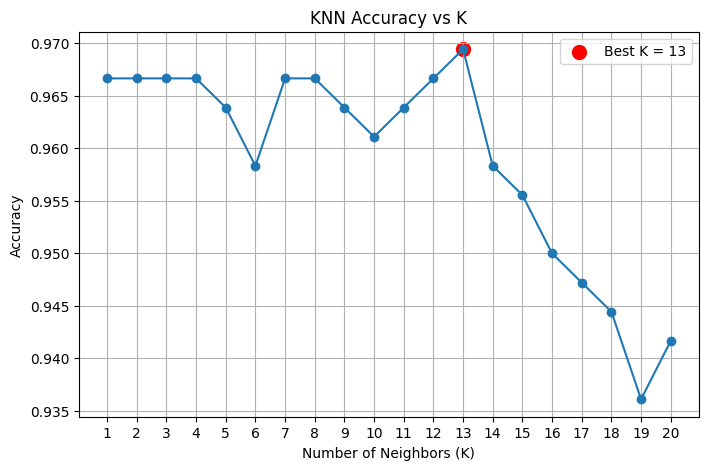

In [124]:
results_df["K"] = results_df["Kernel"].str.extract(r'\((?:K=)(\d+)\)').astype(int)
results_df = results_df.sort_values("K")
best_row = results_df.loc[results_df["Accuracy"].idxmax()]
best_k = best_row["K"]

plt.figure(figsize=(8,5))
plt.plot(results_df["K"], results_df["Accuracy"], marker='o')
plt.scatter(best_k, best_row["Accuracy"], color='red', s=100, label=f"Best K = {best_k}")
plt.xticks(range(1, 21))
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.legend()
plt.grid(True)
plt.show()




The accuracy curve demonstrates that performance remains relatively stable for smaller K values, peaks at K = 13, and gradually decreases for larger K values. This decline at higher K values suggests underfitting, as the model becomes overly smooth and less sensitive to local structure in the data.

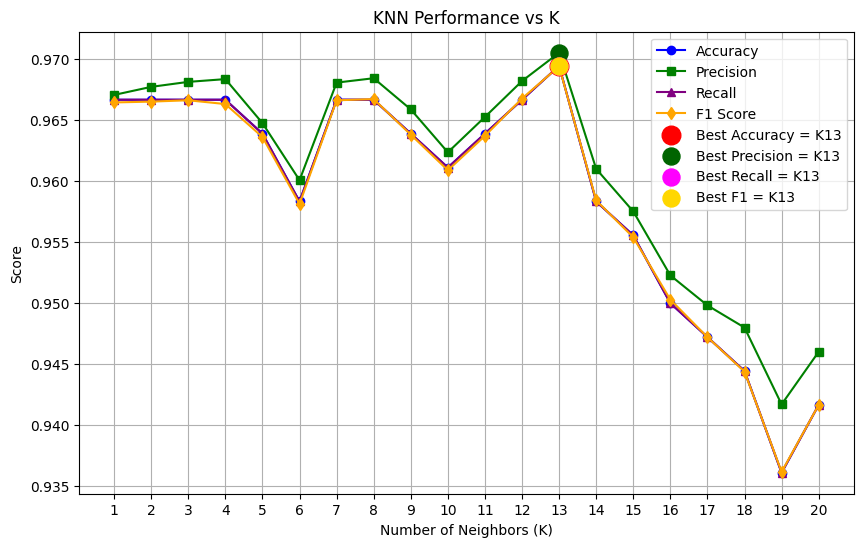

In [125]:
results_df = results_df.sort_values("K")

best_acc = results_df.loc[results_df["Accuracy"].idxmax()]
best_prec = results_df.loc[results_df["Precision"].idxmax()]
best_rec = results_df.loc[results_df["Recall"].idxmax()]
best_f1 = results_df.loc[results_df["F1 Score"].idxmax()]

plt.figure(figsize=(10,6))
plt.plot(results_df["K"], results_df["Accuracy"], marker='o', color='blue', label="Accuracy")
plt.plot(results_df["K"], results_df["Precision"], marker='s', color='green', label="Precision")
plt.plot(results_df["K"], results_df["Recall"], marker='^', color='purple', label="Recall")
plt.plot(results_df["K"], results_df["F1 Score"], marker='d', color='orange', label="F1 Score")
plt.scatter(best_acc["K"], best_acc["Accuracy"],
            color='red', s=180, zorder=5,
            label=f"Best Accuracy = K{best_acc['K']}")

plt.scatter(best_prec["K"], best_prec["Precision"],
            color='darkgreen', s=150, zorder=5,
            label=f"Best Precision = K{best_prec['K']}")

plt.scatter(best_rec["K"], best_rec["Recall"],
            color='magenta', s=150, zorder=5,
            label=f"Best Recall = K{best_rec['K']}")

plt.scatter(best_f1["K"], best_f1["F1 Score"],
            color='gold', s=150, zorder=5,
            label=f"Best F1 = K{best_f1['K']}")
plt.xticks(range(1, 21))

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Score")
plt.title("KNN Performance vs K")
plt.legend()
plt.grid(True)
plt.show()


The trends for precision, recall, and F1-score closely follow the accuracy curve, indicating consistent performance across all evaluation metrics. The alignment of these metrics confirms that the classifier performs uniformly well across all digit classes.

## Conclusion

Overall, the KNN classifier achieved strong performance on the handwritten digits dataset, with the optimal configuration at K = 13 achieving approximately 96.94% accuracy. The results illustrate the importance of selecting an appropriate neighborhood size to balance bias and variance in distance-based classification methods.